In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import polars as pl
from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zhaoyu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from scipy.stats import norm, t
from statsmodels.tsa.stattools import adfuller

### Load data from Tardis

In [3]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

In [ ]:
# Set time and exchanges
start_time = datetime.strptime('2025-05-07', '%Y-%m-%d')
end_time = datetime.strptime('2025-05-20', '%Y-%m-%d')
exchange = 'binance-futures' #'binance-futures'
symbol = 'ethusdt'
                    
# Load the data
# trades_bnc = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_bnc = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
# order_book_bnc_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
# order_book_bnc_10 = order_book_bnc_25.select(order_book_bnc_25.columns[:45])

# Add Latency Column
# trades_bnc, bbo_bnc, order_book_bnc_25, order_book_bnc_10 = [
#     ds.with_columns([
#         (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
#         (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
#     ]).filter(pl.col("next_recv_latency").is_not_null())
#     for ds in [trades_bnc, bbo_bnc, order_book_bnc_25, order_book_bnc_10]
# ]

In [11]:
dec01_ob = order_book_bnc_25
dec01_trades = trades_bnc

In [7]:
aug05_ob = order_book_bnc_25
aug05_trades = trades_bnc

In [11]:
sep10_ob = order_book_bnc_25
sep10_trades = trades_bnc

In [386]:
sep10_ob.with_columns([
    pl.col('timestamp').diff().fill_null(0).alias('timestamp_diff')
]).filter(
    pl.col("timestamp_diff") == pl.col("timestamp_diff").max()
)

human_time,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,…,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,recv_latency,next_recv_latency,timestamp_diff
datetime[μs],str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
2024-09-10 08:00:02.076,"""binance-futures""","""BTCUSDT""",1725955202076000,1725955202079468,57183.2,19.899,57183.1,3.611,57183.3,0.016,57183.0,0.066,57183.4,0.751,57182.6,1.755,57183.5,1.479,57182.4,0.003,57184.0,0.002,57182.3,0.006,57184.9,0.239,57182.0,0.004,57185.0,0.002,57181.8,0.002,57185.1,0.002,57181.3,0.005,…,57179.5,0.315,57187.1,0.304,57179.3,0.006,57187.3,0.304,57179.0,0.002,57187.5,0.02,57178.9,0.202,57187.6,0.05,57178.8,0.006,57187.9,0.003,57178.4,0.035,57188.0,0.347,57178.3,0.314,57188.1,0.025,57178.2,0.003,57188.4,0.5,57178.1,0.786,3468,3860,1989000


In [781]:
sep10_ob.filter(pl.col('local_timestamp')>=1725955199579468).to_pandas().iloc[0:500, :].to_csv('ob_sample.csv')

In [ ]:
sep10_trades.filter(pl.col('timestamp')>=1725955200087000).to_pandas().iloc[:1000, :].to_csv('trades_sample.csv')

In [11]:
# order_book_bnc_10.filter(order_book_bnc_10['timestamp'].diff() < 10000)

### Data Analysis

In [17]:
class EDA():
    def __init__(self, hyper_paras, trades_df):
        self.hp = hyper_paras
        self.trades_df = trades_df
    
    @staticmethod
    def get_single_trade(trades_df: pl.dataframe, trades_amount_threshold: int = 0.01, latency_buffer: int = 5, rv_type: str = 'L2', price_scaler: int = 1) -> pl.dataframe:
        '''
        trades_amount_threshold is the quantity of base, e.g. BTC, which should depends on specific coins, simply for noise filtering
        scaler: we need the rv being int for further operation, so we need to multiply a scaler for some coin whose price is small
        '''
        # Calculate the differences
        trades_df = trades_df.with_columns([
            (pl.col("timestamp").diff().fill_null(0)).alias("ts_diff"),
            (pl.col("local_timestamp").diff().fill_null(0)).alias("lts_diff")
        ])

        # Binning trades
        trades_df = trades_df.with_columns([
            ((pl.col("ts_diff") > 1000)).alias("is_new_bucket") # | (pl.col("lts_diff") > 200)
        ])

        # Calculate bucket_id
        trades_df = trades_df.with_columns([
            pl.col("is_new_bucket").cum_sum().alias("bucket_id")
        ])

        # Calculate bucket statistics
        latency_buffer = latency_buffer * 1000 # to ms
        trades_df_bucket = (
            trades_df.group_by('bucket_id')
            .agg([
                pl.col('timestamp').first().alias('start_time'),
                pl.col('timestamp').last().alias('end_time'),
                pl.col('price').filter(pl.col('side') == 'buy').first().alias('buy_first_price'),
                pl.col('price').filter(pl.col('side') == 'buy').last().alias('buy_last_price'),
                pl.col('amount').filter(pl.col('side') == 'buy').sum().alias('buy_volume'),
                pl.col('price').filter(pl.col('side') == 'sell').first().alias('sell_first_price'),
                pl.col('price').filter(pl.col('side') == 'sell').last().alias('sell_last_price'),
                pl.col('amount').filter(pl.col('side') == 'sell').sum().alias('sell_volume'),
                pl.col('recv_latency').last(),
                (pl.col('timestamp').first() - pl.lit(latency_buffer)).alias('pre_start_time'),
                (pl.col('timestamp').last() + pl.col('recv_latency').last()).alias('local_end_time'),
            ])
            .sort('start_time')
            .fill_null(0)
            )

        # Filter spike with the bucket information
        trades_df_spike = trades_df_bucket.filter(
            (pl.col("buy_volume") >= trades_amount_threshold) | (pl.col("sell_volume") >= trades_amount_threshold)
        )

        # Only choose one side for each trades spike, depends on the volume
        one_side_df = trades_df_spike.with_columns([
                    pl.when(pl.col("buy_volume") > pl.col("sell_volume"))
                    .then(pl.col("buy_first_price"))
                    .otherwise(pl.col("sell_first_price"))
                    .alias("first_price"),

                    pl.when(pl.col("buy_volume") > pl.col("sell_volume"))
                    .then(pl.col("buy_last_price"))
                    .otherwise(pl.col("sell_last_price"))
                    .alias("last_price"),

                    pl.when(pl.col("buy_volume") > pl.col("sell_volume"))
                    .then(pl.col("buy_volume"))
                    .otherwise(pl.col("sell_volume"))
                    .alias("volume")
                ])

        # Apply price scaler
        one_side_df = one_side_df.with_columns([
            pl.col('first_price') * price_scaler,
            pl.col('last_price') * price_scaler,
        ])

        # Add reliazed volatility for each trades spike
        if rv_type == 'L2':
            rv_df = one_side_df.with_columns([
                (((pl.col('first_price') - pl.col('last_price')))**2)
                .alias('rv')
            ])

        elif rv_type == 'L1':
            rv_df = one_side_df.with_columns([
                (((pl.col('first_price') - pl.col('last_price'))).abs()).alias('rv')
            ])

        return rv_df


    @staticmethod
    def add_rolling_trades_features(df: pl.dataframe, time_period: str = '15', count_period: str = '30', rolling_method: str = 'sum') -> pl.dataframe:
        '''
        Each feature represent the information we would see and can use after absorbing new information (each new row)
        '''
        # Add rolling trades features
        if rolling_method == 'sum':
            df = df.with_columns([
                pl.sum("rv").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_rv_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.sum("rv").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_rv_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
                pl.sum("volume").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_volume_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.sum("volume").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_volume_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
            ])
        elif rolling_method == 'mean':
            df = df.with_columns([
                pl.mean("rv").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_rv_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.mean("rv").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_rv_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
                pl.mean("volume").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_volume_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.mean("volume").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_volume_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
            ])
        elif rolling_method == 'max':
            df = df.with_columns([
                pl.max("rv").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_rv_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.max("rv").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_rv_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
                pl.max("volume").rolling(index_column="local_end_time", period=f"{time_period}000000i").alias(f'rolling_{rolling_method}_volume_{time_period}s'), # Add sum realized volatility per trade in last 15s
                pl.max("volume").rolling(index_column="index", period=f"{count_period}i").alias(f'rolling_{rolling_method}_volume_{count_period}T'), # Add sum realized volatility per trade in last 30 trades
            ])

        return df
    

    @staticmethod
    def add_rolling_time_features(df: pl.dataframe, min_unit: str = '1s', candle_period: str = '15s', rolling_method: str = 'sum') -> pl.dataframe:    
        # Add rolling trades features, time we used the exch_time instead of local time to get the universal volatility despite the machine
        df = df.with_columns([
            pl.col("end_time").cast(pl.Datetime).alias("end_datetime"),
        ])

        # Get time bucket feature (OHLCV)
        # Note that the label=right is because of the "can see" rule, only at end of each second, we can have the following information. (which will be merged back, so we need to be able to see the data at given timestamp)
        candlestick = df.group_by_dynamic("end_datetime", every=min_unit, closed="right", include_boundaries=True, label='right').agg([
            pl.col("first_price").first().alias('Open'),
            pl.col("last_price").last().alias('Close'),
            pl.max_horizontal(
                    pl.col("first_price").max(),
                    pl.col("last_price").max()
            ).alias('High'),
            pl.min_horizontal(
                    pl.col("first_price").min(),
                    pl.col("last_price").min()
            ).alias('Low'),
            pl.col("volume").sum().alias('Volume'),
        ])

        # Add time rv for each 1s
        candlestick = candlestick.with_columns([
            ((pl.col('Open') - pl.col('Close'))**2).alias('rv_open_close'),
            ((pl.col('High') - pl.col('Low'))**2).alias('rv_high_low')
        ])

        # customize features
        if rolling_method == 'sum':
            candlestick = candlestick.select([
                pl.col("end_datetime"),
                pl.sum("rv_open_close").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_oc_{candle_period}'), # Add sum realized volatility derived from open - close for past 15s
                pl.sum("rv_high_low").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_hl_{candle_period}'), # Add sum realized volatility derived from high - low for past 15s
                pl.sum("Volume").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_v_{candle_period}'), # Add sum volume
            ])
        elif rolling_method == 'mean':
            candlestick = candlestick.select([
                pl.col("end_datetime"),
                pl.mean("rv_open_close").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_oc_{candle_period}'), # Add sum realized volatility derived from open - close for past 15s
                pl.mean("rv_high_low").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_hl_{candle_period}'), # Add sum realized volatility derived from high - low for past 15s
                pl.mean("Volume").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_v_{candle_period}'), # Add sum volume
            ])
        elif rolling_method == 'max':
            candlestick = candlestick.select([
                pl.col("end_datetime"),
                pl.max("rv_open_close").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_oc_{candle_period}'), # Add sum realized volatility derived from open - close for past 15s
                pl.max("rv_high_low").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_rv_hl_{candle_period}'), # Add sum realized volatility derived from high - low for past 15s
                pl.max("Volume").rolling(index_column="end_datetime", period=candle_period).alias(f'rolling_{rolling_method}_v_{candle_period}'), # Add sum volume
            ])

        # Merge the rv data back to original dataframe
        res = df.join_asof(
                candlestick, 
                left_on='end_datetime', 
                right_on='end_datetime', 
                strategy='backward'
            )

        return res

    
    @staticmethod
    def add_rolling_target(df: pl.dataframe, bar_bps: int, rolling_method: str = 'max') -> pl.dataframe:
        '''
        Key idea is to find a good proxy (target variable) for real trading activity.

        Sample Methods: 
            Plan A: Add biggest trade before price went up n bps (can try different n, from 1-9) - issue: can't determine the correct price if bbo spread wide, and hard to implement
            Plan B: RV accumulate (price delta ^ 2)

        Target Candidate:
            For Sample B, can try model with 'mean', 'max' or 'median', then backtest the res finally

        PARAMS:
            bar_bps: Plan B, need to specify RV accumulate amount for each bar (depends on the vol of certain asset).
                     For BTC, we can use 2-4 bps, reference: non-zero rv 0.99 quantile is 151.29 (2bps of price change square)
        '''
        # Reverse the order for rolling operation
        df_reverse_sort = df.sort('start_time', descending = True)

        # Shift operation because what we need is slightly different than what rolling can give us (we wanna include the last row before move to next group, and exclude it from next group)
        df_reverse_sort = df_reverse_sort.with_columns([
            pl.col('rv').shift(1).alias(f'next_trade_rv'),
            pl.col('volume').shift(1).alias(f'next_trade_volume'),
            (pl.col('rv') / pl.col('volume')).shift(1).alias(f'next_trade_ob_strength'),
            pl.col('rv').shift(1).cum_sum().cast(pl.Int32).alias(f'cum_sum_rv'),
        ]).fill_null(0)

        # Rolling Group by price bar
        bar_abs = int((bar_bps / 10000 * df['first_price'][0]) ** 2)
        bar_abs_str = f"{bar_abs}i"

        if rolling_method == 'max':
            res = df_reverse_sort.with_columns([
                pl.max('next_trade_rv').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'rv_rolling_max_{bar_abs_str}'),
                pl.col("next_trade_volume").filter(pl.col("next_trade_rv") == pl.col("next_trade_rv").max()).get(0).rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'volume_rolling_max_{bar_abs_str}'),
                pl.col("next_trade_ob_strength").filter(pl.col("next_trade_rv") == pl.col("next_trade_rv").max()).get(0).rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'ob_strength_rolling_max_{bar_abs_str}'),
            ])
        elif rolling_method == 'mean':
            res = df_reverse_sort.with_columns([
                pl.mean('next_trade_rv').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'rv_rolling_mean_{bar_abs_str}'),
                pl.mean('next_trade_volume').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'volume_rolling_mean_{bar_abs_str}'),
                pl.mean('next_trade_ob_strength').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'ob_strength_rolling_mean_{bar_abs_str}')
            ])
        elif rolling_method == 'sum':
            res = df_reverse_sort.with_columns([
                pl.sum('next_trade_rv').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'rv_rolling_sum_{bar_abs_str}'),
                pl.sum('next_trade_volume').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'volume_rolling_sum_{bar_abs_str}'),
                pl.sum('next_trade_ob_strength').rolling(index_column=f"cum_sum_rv", period=bar_abs_str).alias(f'ob_strength_rolling_sum_{bar_abs_str}')
            ])

        res = res.drop(["next_trade_rv", "next_trade_volume", 'next_trade_ob_strength', "cum_sum_rv"])

        # Revert back to original order
        return res.sort('start_time', descending = False)

    
    @staticmethod
    def plot_feature_target(df: pd.DataFrame, target_col: str, quantile_x=False, quantile_y=True) -> None:
        # Define the columns to plot against "time"
        columns_to_plot = df.columns[17:]

        # Only keep features columns
        columns_to_plot = [item for item in columns_to_plot if item.endswith('T') or item.endswith('s')]

        # Create a 2x4 grid of subplots
        row_num = len(columns_to_plot)//4 + 1
        fig, axes = plt.subplots(row_num, 4, figsize=(30, 40))

        # Flatten the axes array for easy indexing
        axes = axes.flatten()

        # Plot each column in a subplot
        df_plot = df.copy()
        if quantile_y:
            df_plot[target_col] = df[target_col].rank(pct=True)
            
        for i, col in enumerate(columns_to_plot):        
            if quantile_x:
                df_plot[col] = df[col].rank(pct=True)
            
            axes[i].scatter(df_plot[col], df_plot[target_col])
            axes[i].set_title(f"{col} vs {target_col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel(target_col)

        # Adjust layout for better readability
        plt.tight_layout()
        plt.show()
    
    
    def run_EDA(self):
        trades_df = self.trades_df
        hp_filter = self.hp
        
        # Calculate single trades
        single_trades = self.get_single_trade(trades_df, trades_amount_threshold = hp_filter.amt_thresh, rv_type = hp_filter.rv_tpye)
        single_trades = single_trades.with_row_index()
        
        # Add trades and OHLCV features
        df_features_added = single_trades
        for rolling_method in ['sum', 'mean', 'max']:
            df_features_added = self.add_rolling_trades_features(df_features_added, time_period = hp_filter.trades_time_window, count_period = hp_filter.trades_count_window, rolling_method = rolling_method)
            df_features_added = self.add_rolling_time_features(df_features_added, min_unit = hp_filter.candle_min_unit, candle_period = hp_filter.candel_time_window, rolling_method = rolling_method)

        # Add extra order book strength features
        df_features_added = df_features_added.with_columns([
            (pl.col('rolling_sum_rv_15s') / pl.col('rolling_sum_volume_15s')).alias('rolling_sum_ob_15s'),
            (pl.col('rolling_sum_rv_30T') / pl.col('rolling_sum_volume_30T')).alias('rolling_sum_ob_30T'),
            (pl.col('rolling_sum_rv_oc_15s') / pl.col('rolling_sum_v_15s')).alias('rolling_sum_ob_oc_15s'),
            (pl.col('rolling_sum_rv_hl_15s') / pl.col('rolling_sum_v_15s')).alias('rolling_sum_ob_hl_15s'),
        ])
        
        # Add target
        df_target_added = add_rolling_target(df_features_added, rolling_method = hp_filter.target_type, bar_bps = hp_filter.target_bps_window)

        # Extra data filtration 
        
        # FILTER 1 - We don't make prediciton if last latency is high
        df_normal_latency = df_target_added.with_columns([
            pl.col('recv_latency').shift(1).alias('prev_latency')
        ])
        df_normal_latency = df_normal_latency.fill_null(0).filter(pl.col('prev_latency') <= hp_filter.latency_thresh).drop('prev_latency')
        
        # FILTER 2 - Subset conditional on particular features
        df_pandas = df_normal_latency.filter(
                        pl.col(hp_filter.plot_cond_feature) >= hp_filter.plot_cond_feature_lower_bound
                    ).to_pandas()
        
        # FILTER 3 - We don't update our prediction after small trades, so only those big trades that matters
        df_plot = df_pandas[df_pandas['rv'] >= hp_filter.plot_rv_threshold]
        
        # Print the filtration sample ratio
        print(f"{df_normal_latency.shape[0]} out of {df_target_added.shape[0]} samples remains after high latency filtration")
        print(f"{df_pandas.shape[0]} out of {df_normal_latency.shape[0]} samples remains after conditioning on {hp_filter.plot_cond_feature} >= {hp_filter.plot_cond_feature_lower_bound}")
        print(f"{df_plot.shape[0]} out of {df_pandas.shape[0]} samples remains after select trades whose rv >= {hp_filter.plot_rv_threshold}")
        
        # Plot
        self.plot_feature_target(df_plot, target_col = hp_filter.plot_target_col)
        

In [20]:
from dataclasses import dataclass

@dataclass
class DataProcessParas:
    # Single trade definition
    amt_thresh: float = 0.1
    rv_tpye: str = 'L2'
    
    # Features rolling parameters - based on trades
    trades_time_window: int = 15 # seconds
    trades_count_window: int = 30 # past 30 trades
    
    # Features rolling parameters - based on candlestick (OHLCV)
    candle_min_unit: str = '1s'
    candel_time_window: str = '15s'
    
    # Target rolling parameters
    target_type: str = 'max' # Can think more about it
    target_bps_window: int = 4 # Can think more about it
    
    # Data filtration before plot (affect the z-score calculation)
    latency_thresh: int = 20000
    
    # Data filtration during plot (didn't affect the z-score calculation)
    plot_cond_feature: str = 'rolling_max_rv_15s' # Conditional features
    plot_cond_feature_lower_bound: int = 0 # Conditional features lower bound
    plot_target_col: str = 'ob_strength_rolling_max_520i' # Target varable name
    plot_rv_threshold: int = 0 # Not bps, but abs value. Only plot trade whose rv is above the threshold (idea is that we only update information after big trades)

#### Test

195094 out of 196957 samples remains after high latency filtration
195094 out of 195094 samples remains after conditioning on rolling_max_rv_15s >= 0
2873 out of 195094 samples remains after select trades whose rv >= 36


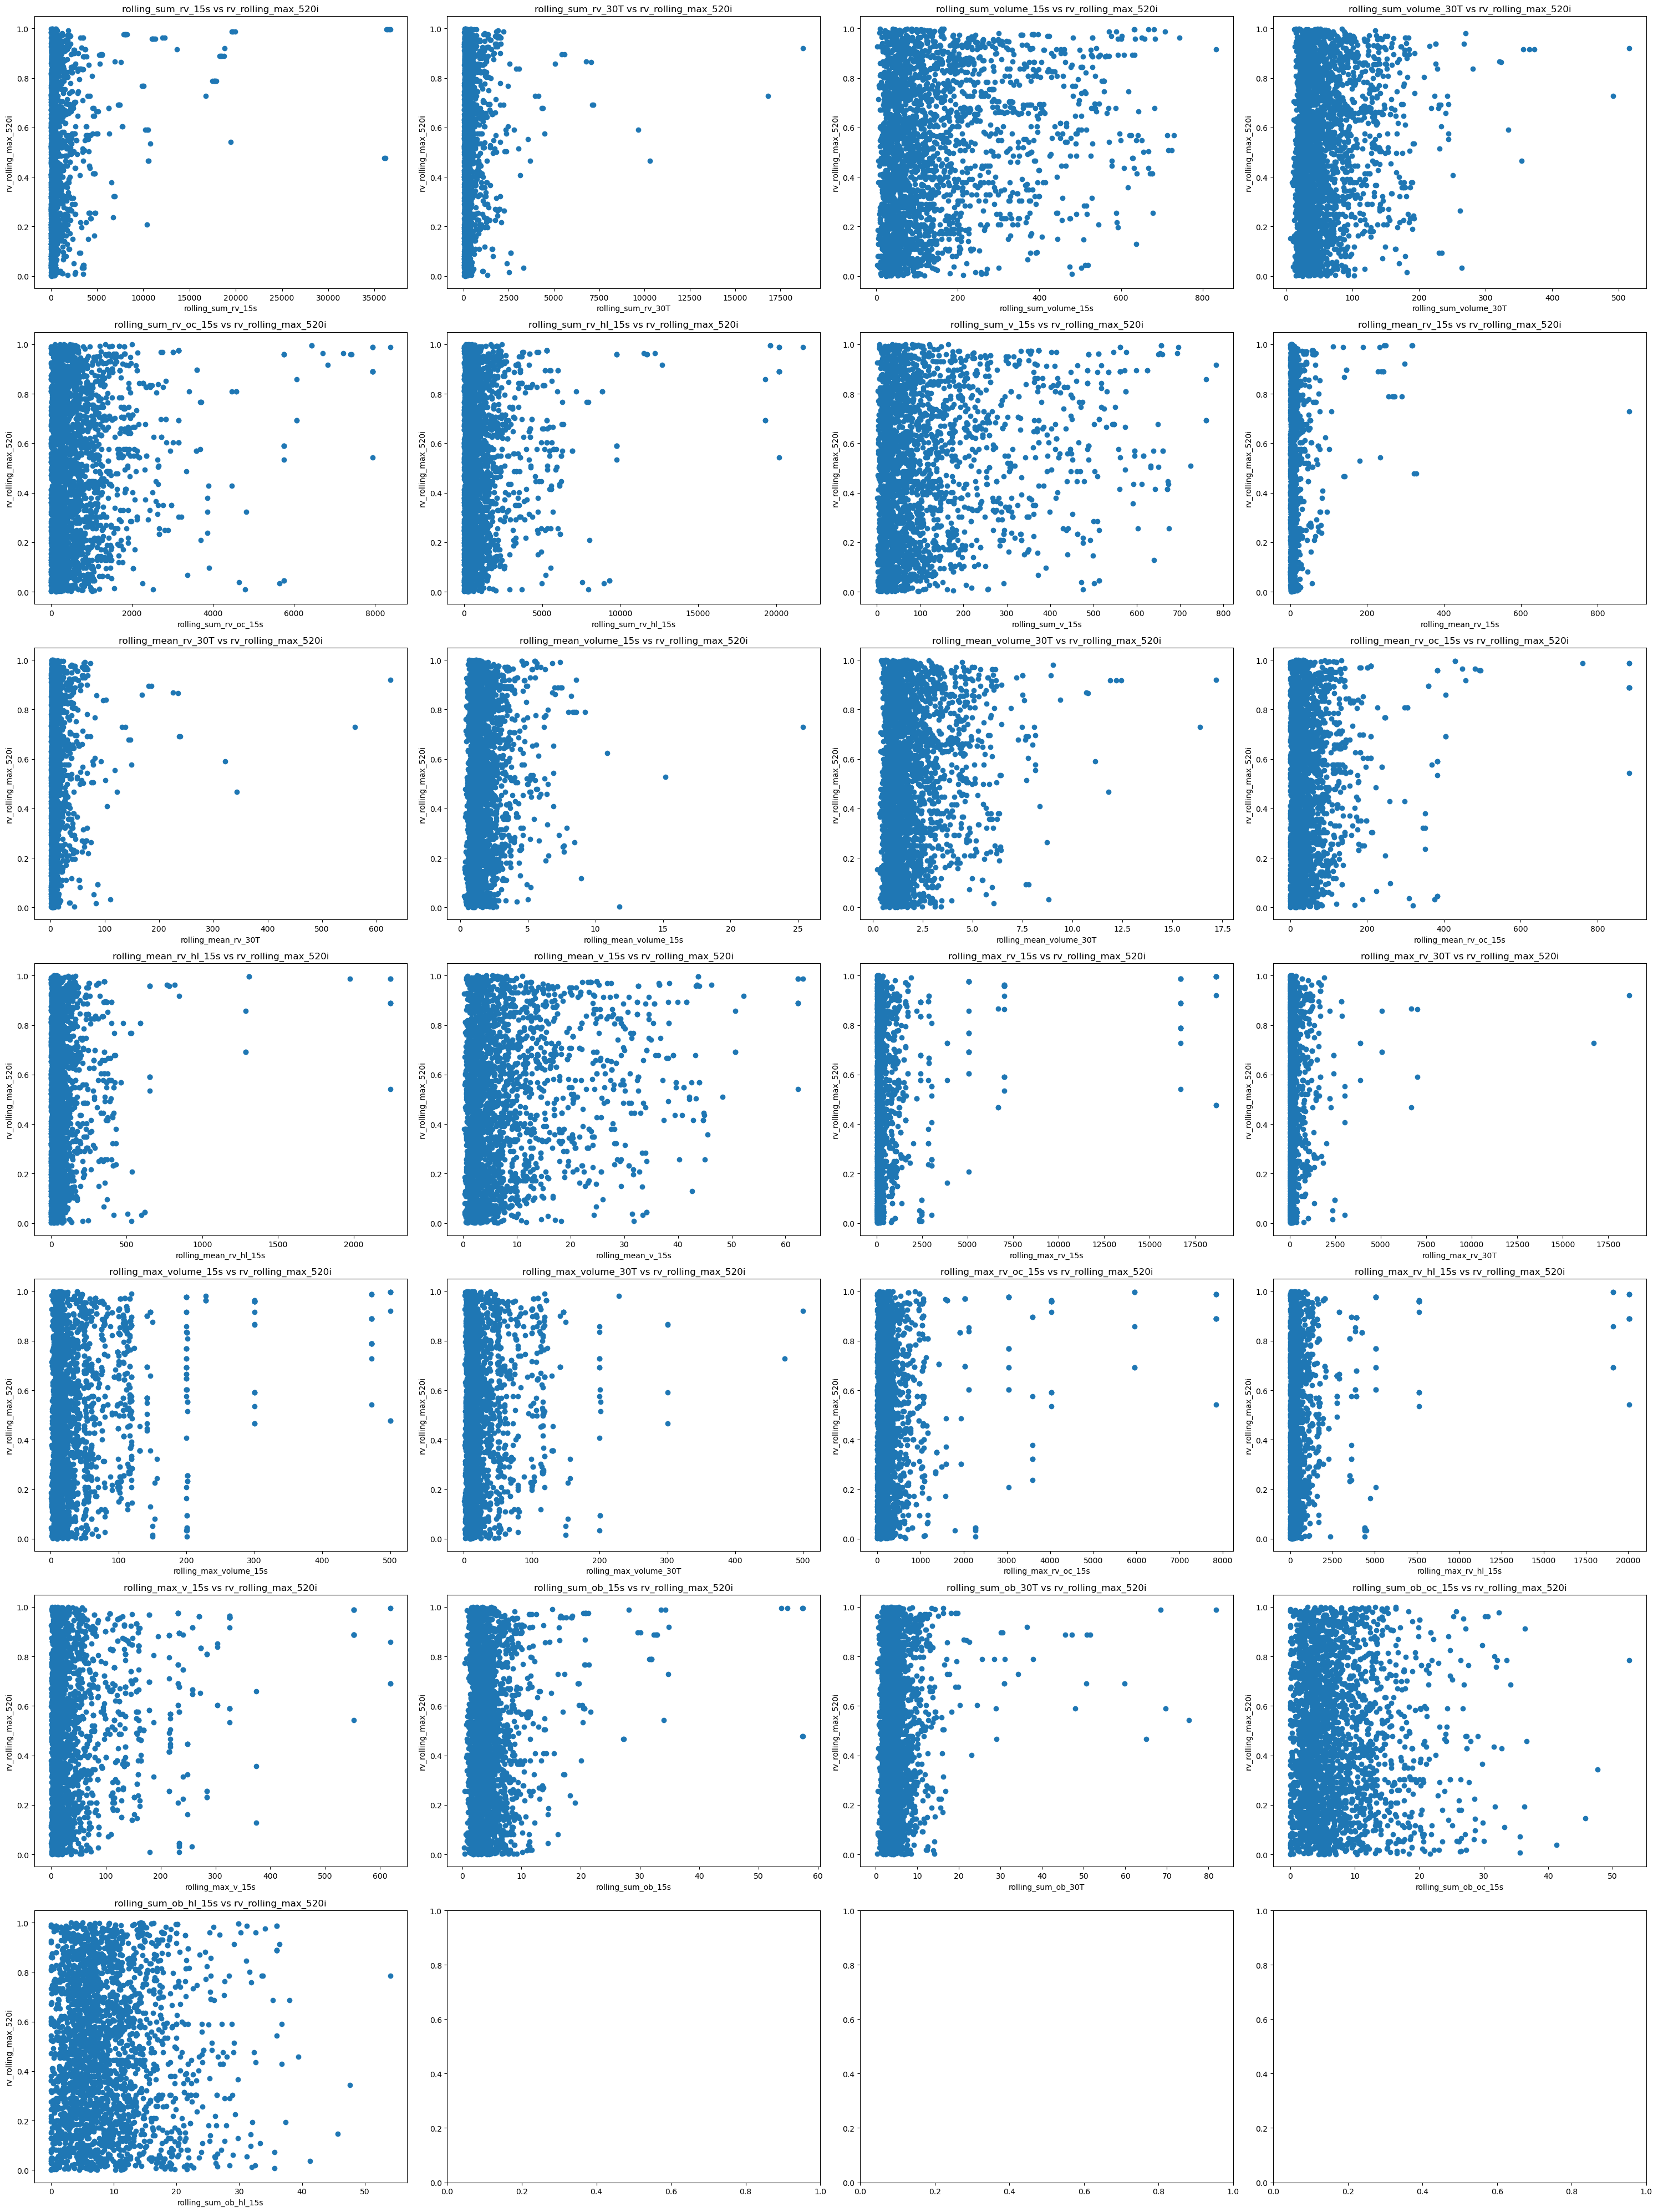

In [326]:
hp_filter = DataProcessParas(plot_rv_threshold=36, plot_target_col = 'rv_rolling_max_520i')
eda = EDA(hp_filter, sep10_trades)
eda.run_EDA()

195094 out of 196957 samples remains after high latency filtration
195094 out of 195094 samples remains after conditioning on rolling_max_rv_15s >= 0
2873 out of 195094 samples remains after select trades whose rv >= 36


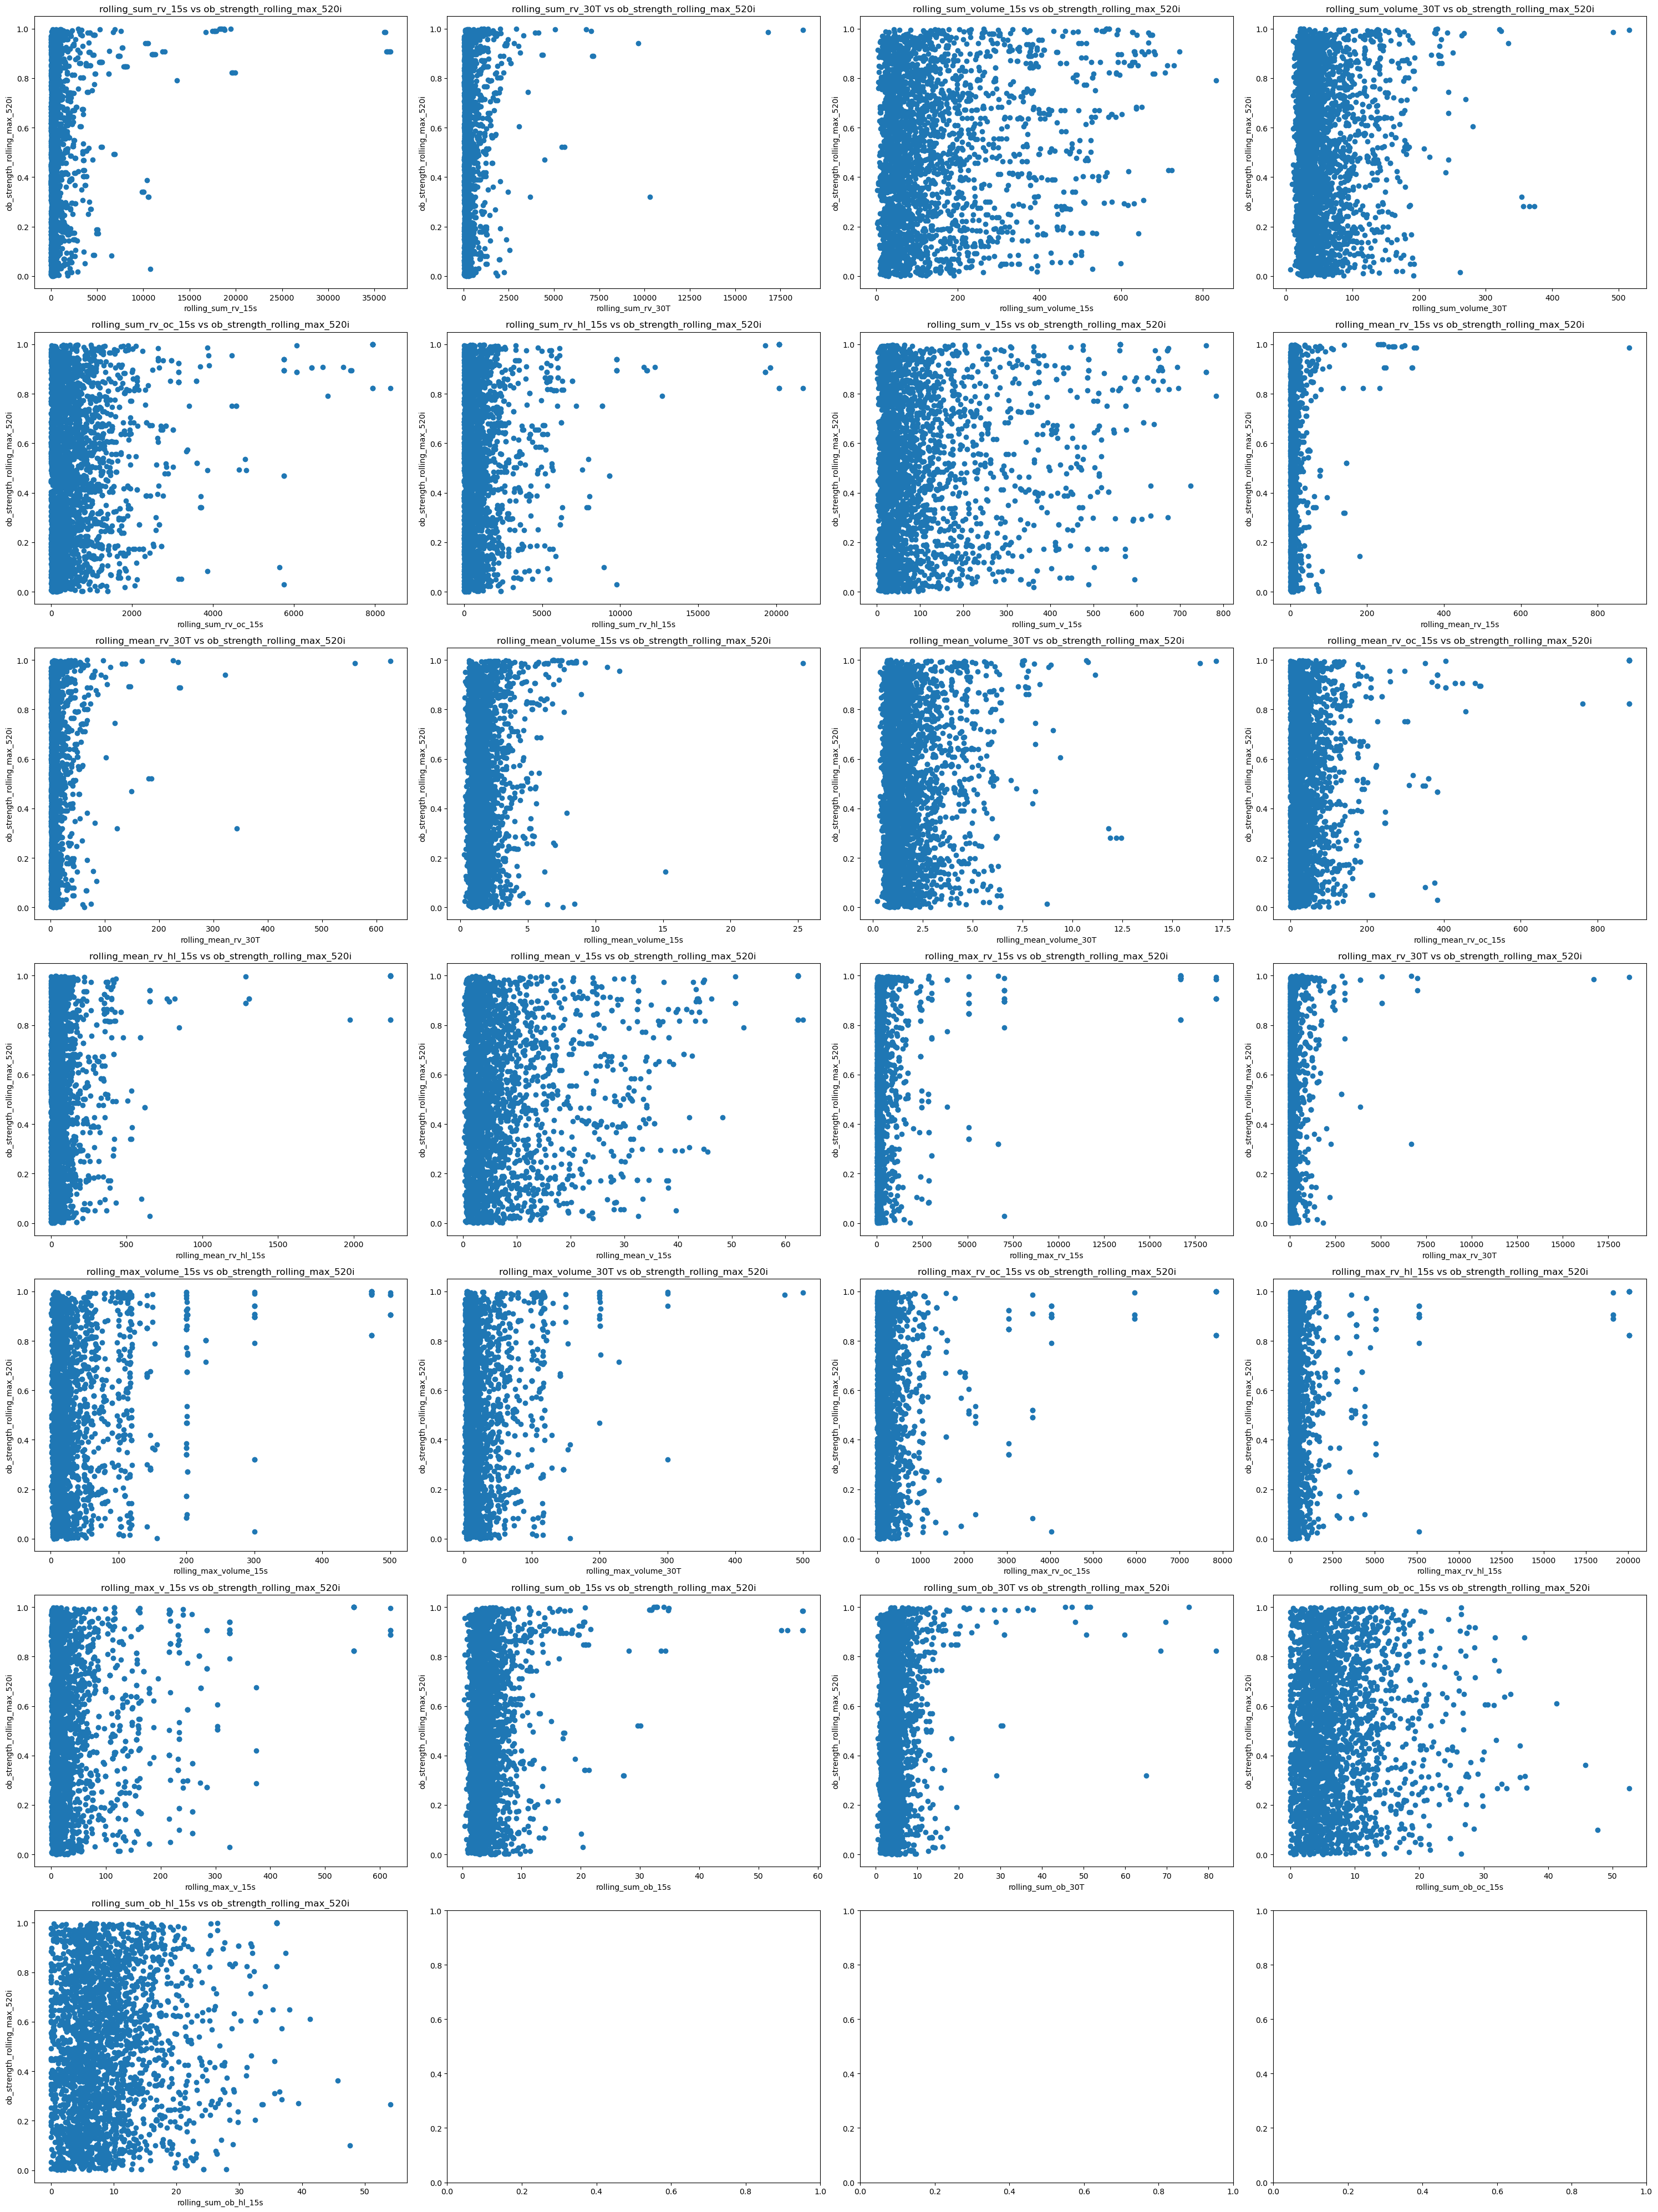

In [324]:
hp_filter = DataProcessParas(plot_rv_threshold=36)
eda = EDA(hp_filter, sep10_trades)
eda.run_EDA()

195094 out of 196957 samples remains after high latency filtration
195094 out of 195094 samples remains after conditioning on rolling_max_rv_15s >= 0
195094 out of 195094 samples remains after select trades whose rv >= 0


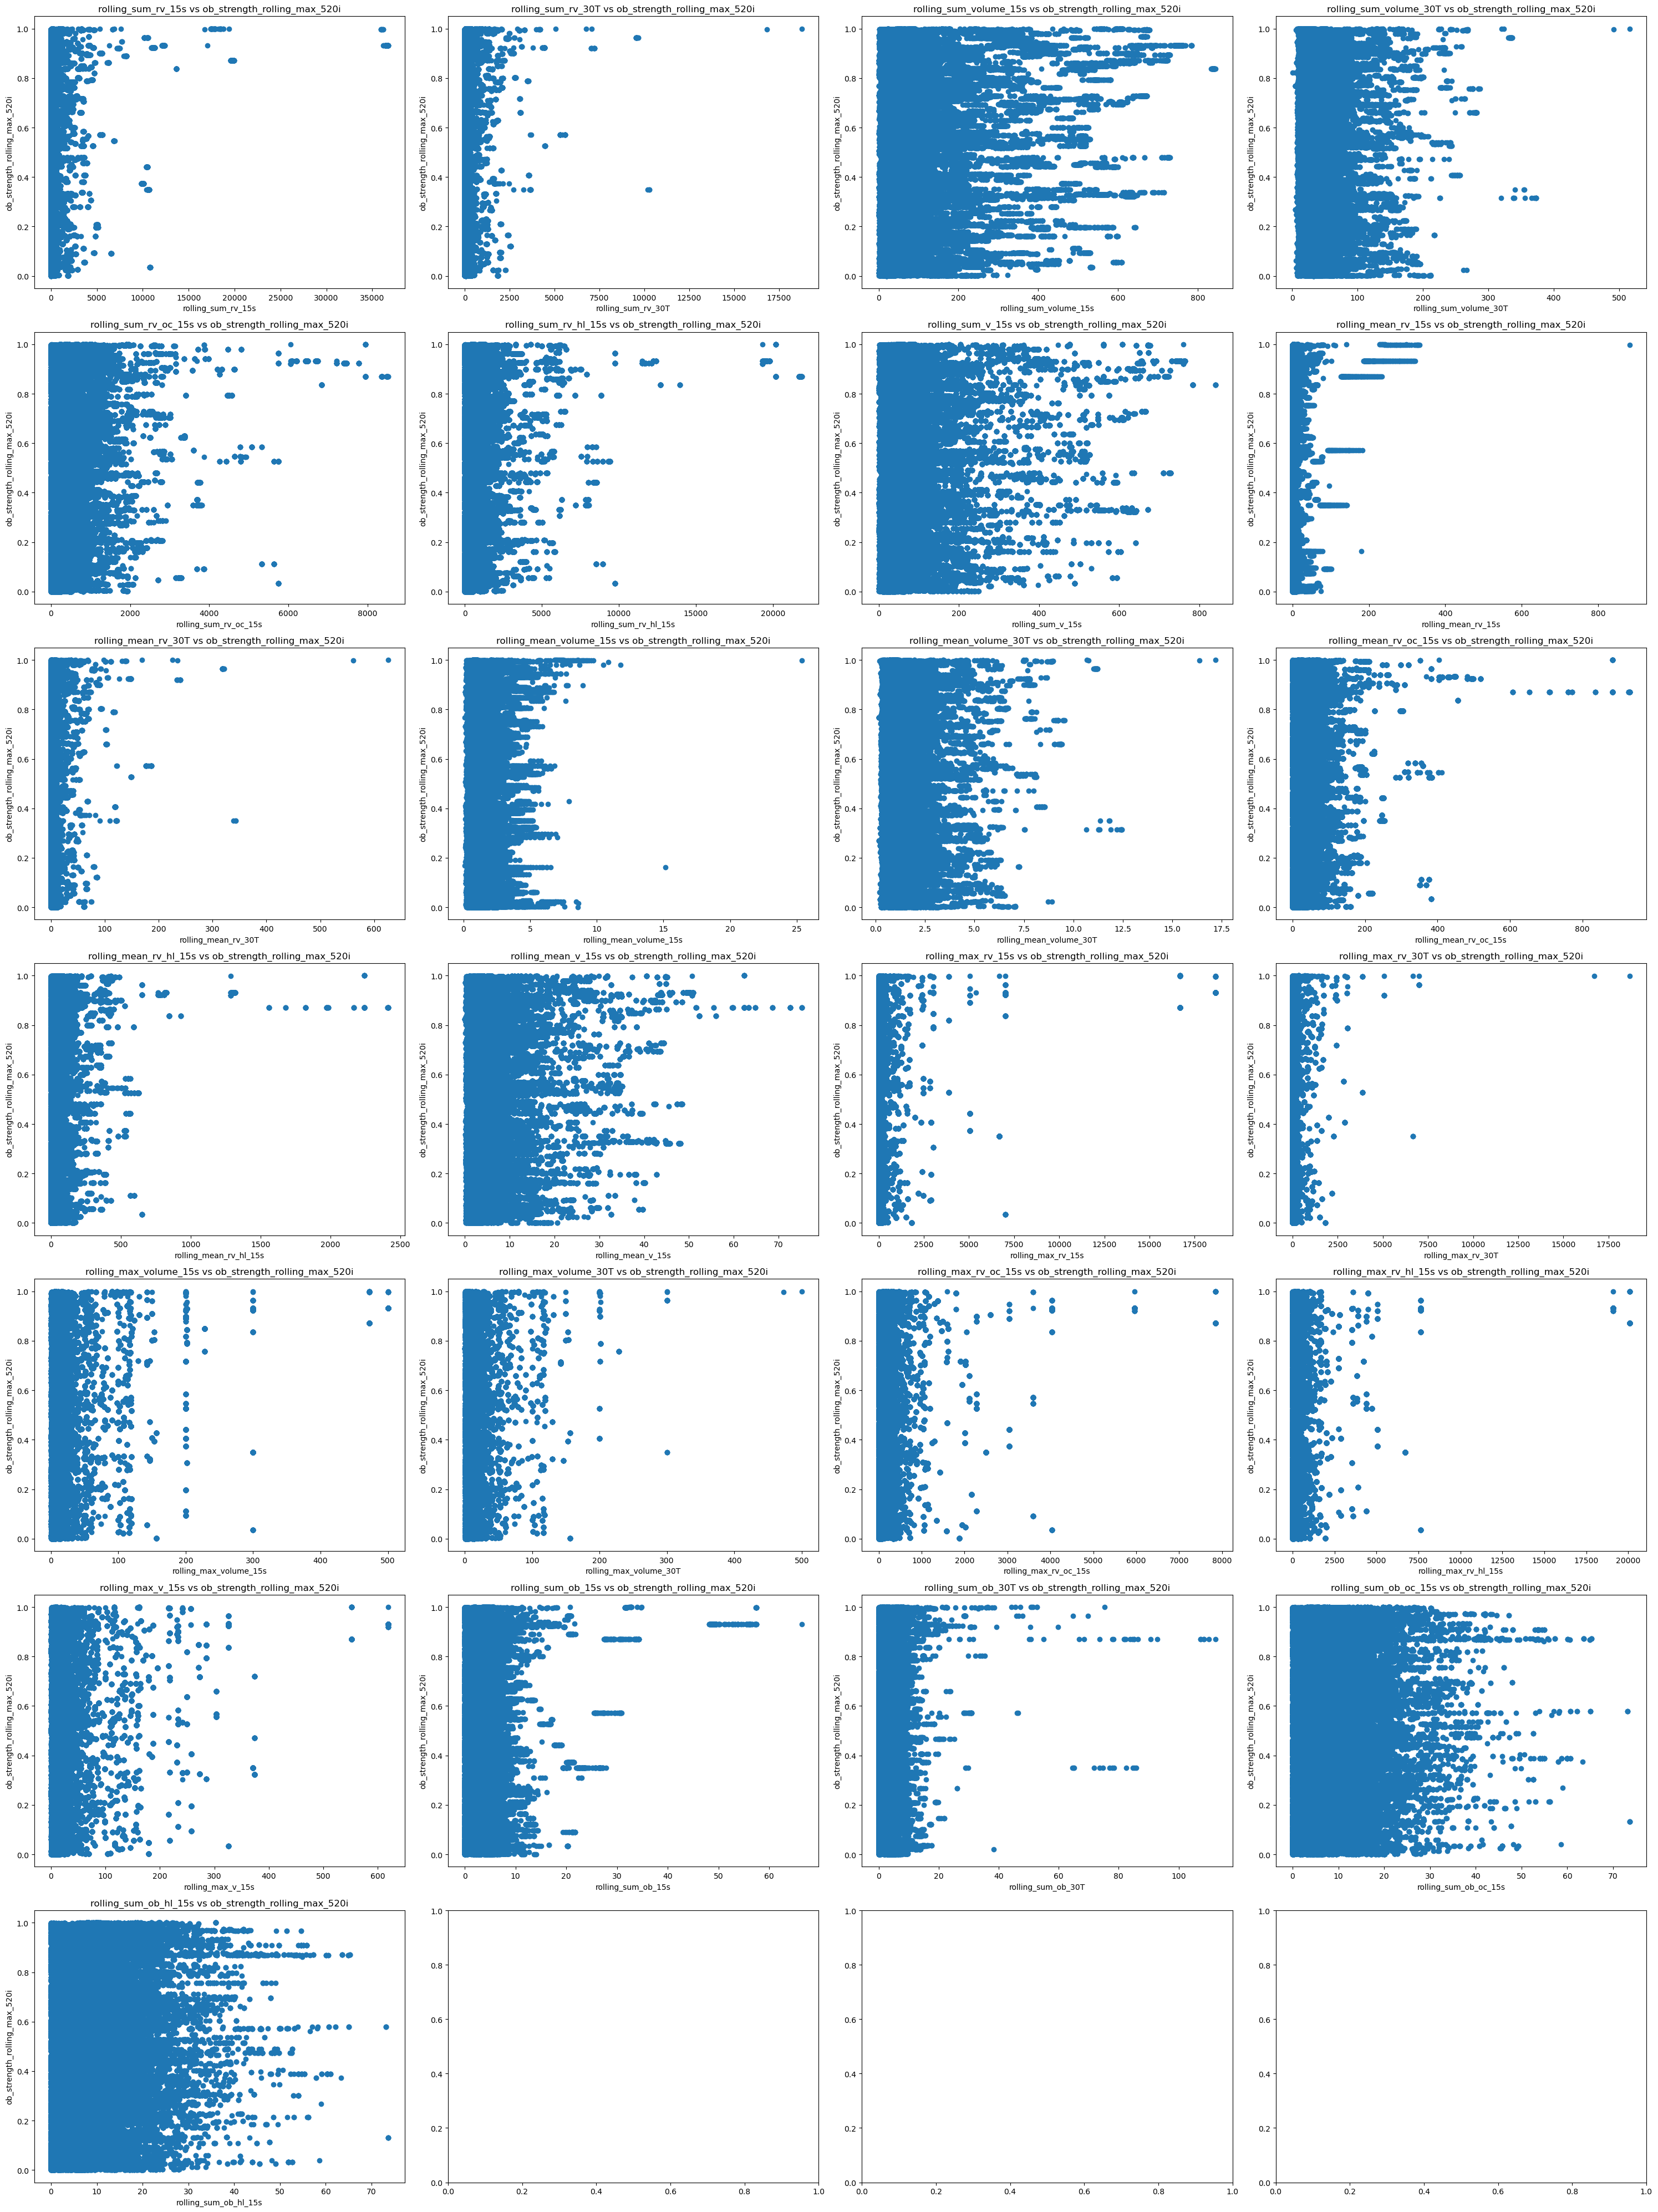

In [118]:
hp_filter = DataProcessParas()
eda = EDA(hp_filter, sep10_trades)
eda.run_EDA()

##### 临时的一些结论:

1. L1 rv 相比于 L2 rv来说完全没有啥信息
2. 需要用quantile来处理y (否则几乎没有什么信息) - 因为我们无法预测第一次spike, 我们的假设只是, 在spike发生后的波动会变大
3. 目前的解释是: 首先, 当rolling波动很低时, 未来是否会出现波动更接近随机, 而当rolling波动超过一定的阈值, 可以发现一个线性的关系. (这也符合我们真实的交易, 也即, 大部分时间不需要改变spread, 只是在出现了极端行情之后的一小段时间内, 我们需要改变spread)
4. 树模型的探讨: 举个例子就是, 先用rv_rolling_15s筛选一次样本, 然后对筛选之后的样本, 用rv_rolling_30T进行线性回归 (即15s判断环境vol, 30T作为事件vol, 几个结合进行判断)
5. 对比筛选掉高延迟样本前后, 发现筛选掉高延迟样本后的图变化还是很明显的, 主要是高波动地方样本删除了一些 (最合理的话还是要剔除高延迟样本的预测)



接下来未完成:
1. 图上新增中值点, 对部分x
2. 对一些特征做线性回归, 然后代入回测系统中
3. rv/volume filter, 因为我们并不是在所有trade之后都重新评估, 而是只在重要trade之后重新评估. 这样做的目的是避免大量不重要的trade共享同一个target, 从而影响回归结果.


其他想法:
1. 我们无法预测是否之后会有某个大单出现, 我们的假设只是, 在“大单”出现之后, 市场会短期缺少流动性, 造成波动(做市商过度成交). 这个假设是比较合理的
2. 也因此, 我们的线性回归应该是, 在量/rv积累到一定threshold之后, 已经足够对市场产生影响了, 我们这个时候才需要对自己的spread进行调整. 也即, 先filter, 然后做回归
3. 而且, 不仅是filter低波动部分(我们无法预测之后会发生什么). 而且可以filter高波动部分(波动太高, 我们干脆选择不要交易, 而不是用一个很极限的spread). 其实极限spread也接近不要交易了
4. 这个也是符合我们的数据观察, 抑或是交易经验, 也即, 绝大部分时候我们都不需要管spread, 出现大交易大波动的时间其实很短暂, 可能只有1%的时间, 我们需要根据波动情况扩大spread

不同的c:
1. c: 就只有一个volume filter (对Single Trade的)
2. c_1: L1的rv (不行)
3. c_2: 在volume filter基础上还有一个bps filter


Rule Based: (Baseline model)

1. 15s时间窗口内有一个大volume trades(除以rolling std), 立马增大spread (有Informed风险)
2. match z-score of moving avg of vol to pre-setting spread range.


LR Model

1. find the relationship between Features and Informed ratio (No need to do rank, it was automately 0-1)
    1.1 Informed ratio can be normalized by divide the rolling vol std
2. Apply ratio to spread (0-1 * pre-setting spread range)

LR模型问题在于, informed ratio要考虑到低vol的时候我们要降低spread. (也即, 要思考informed ratio如何将时间效应也考虑进去?)
也即informed ratio不仅是bid over ask ratio是否接近50% (低vol和high vol可能同样的informed ratio, 但低vol需要其他乘数考虑环境vol)
(在检验制定的Target有效性之前, 可以直接先把未来Target代入回测看看结果)
    Target: 可以是未来15T, bid rv / ask rv, 也可以是未来15T, bid count / ask count, 或者bid volume / ask volume
    还可以是, 未来5bps之内, bid count / ask count, bid volume / ask volume
    感觉T和bps利于计算, 但是会带来一些不稳定的noise, 是否应该用seconds, 未来5s内? 或者仅仅filter接下来10个bps变化大于1的trades, 然后算count, volume之类的.
    或者还是说, 应该算接下来

总之这个应该是trades是否携带信息的proxy
有几个场景: 1. 比如不能说后面有上涨/下跌, 前面所有的trades都是informed 2. 如果用seconds bucket的话, 会有一点不均衡就是volume很大, 但是方向可能只是一方略微大于另一方, 造成结果很随机, 带来噪声. 3. 单纯考虑交易, 人家可能是prep trading之类的, 太多随机性质, 无法真实确定怎么定义informed trades

哪个target更接近实际交易? (可以分别target带入回测)
哪个target更容易make sense?

制定出来之后, 我们期望可以看到一个时间效应(比如美股交易时间spread更大, 周末spread更小), 以及一个event based临时spread增大.